# 06 Model Analysis & Interpretation

**Goal:** Understand *why* our models work and where they fail.

**Current Best:** CatBoost F1=0.8429 | AUC=0.9780 (V10 Winning Features)

**Sections:**
1. Model Performance Summary
2. Correlation Analysis
3. Feature Importance (3-Model Comparison)
4. SHAP Values
5. Feature Interaction (CatBoost)
6. Feature Distributions (Fraud vs Legit)
7. Precision–Recall & ROC Curves
8. Confusion Matrix & Error Analysis
9. Calibration Curve
10. Research Conclusions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score, roc_curve, 
                             precision_recall_curve, confusion_matrix, classification_report)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

## Load V10 Data & Retrain Models (Quickly)

In [3]:
train = pd.read_pickle('../data/processed/train_v10_winning_fe.pkl')
drop_cols = ['isFraud', 'TransactionID', 'uid', 'uid_d1n', 'trans_hour']
X = train.drop(columns=drop_cols)
y = train['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
cat_cols = X_train.select_dtypes(include=['category', 'object']).columns.tolist()
print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X.shape[1]}')

Train: 472,432 | Test: 118,108 | Features: 481


In [4]:
#LightGBM
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

lgb_model = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, num_leaves=31,random_state=42, n_jobs=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
              categorical_feature=cat_cols,
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])
lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

#XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train_xgb[col], X_test_xgb[col]], axis=0).astype(str)
    le.fit(combined)
    X_train_xgb[col] = le.transform(X_train_xgb[col].astype(str))
    X_test_xgb[col] = le.transform(X_test_xgb[col].astype(str))
for df in [X_train_xgb, X_test_xgb]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(-999, inplace=True)

xgb_model = xgb.XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=6, subsample=0.8, colsample_bytree=0.8, tree_method='hist', random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train_xgb, y_train, eval_set=[(X_test_xgb, y_test)], verbose=False)
xgb_proba = xgb_model.predict_proba(X_test_xgb)[:, 1]

# --- CatBoost ---
cat_features_idx = [X_train.columns.get_loc(c) for c in cat_cols]
X_train_cat = X_train.copy()
X_test_cat = X_test.copy()
for col in cat_cols:
    arr_train = np.array(X_train_cat[col], dtype=object)
    arr_test = np.array(X_test_cat[col], dtype=object)
    arr_train[pd.isna(arr_train)] = 'missing'
    arr_test[pd.isna(arr_test)] = 'missing'
    X_train_cat[col] = arr_train
    X_test_cat[col] = arr_test
cat_model = CatBoostClassifier(iterations=2000, learning_rate=0.05, depth=8, l2_leaf_reg=3,random_seed=42, verbose=False, early_stopping_rounds=100,grow_policy='Lossguide', task_type='GPU', devices='0')
cat_model.fit(X_train_cat, y_train, cat_features=cat_features_idx, eval_set=(X_test_cat, y_test), verbose=False)
cat_proba = cat_model.predict_proba(X_test_cat)[:, 1]

print('All 3 models trained.')

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.228222 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49850
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 480
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.034989 -> initscore=-3.317101
[LightGBM] [Info] Start training from score -3.317101
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[1000]	valid_0's binary_logloss: 0.0440115
All 3 models trained.


## 1. Model Performance Summary

In [5]:
def score_model(name, y_true, y_proba, thresh=0.25):
    preds = (y_proba >= thresh).astype(int)
    return {
        'Model': name,
        'F1': round(f1_score(y_true, preds), 4),
        'Recall': round(recall_score(y_true, preds), 4),
        'Precision': round(precision_score(y_true, preds), 4),
        'AUC': round(roc_auc_score(y_true, y_proba), 4),
        'Best_Thresh': thresh
    }

summary = pd.DataFrame([
    score_model('LightGBM', y_test, lgb_proba),
    score_model('XGBoost', y_test, xgb_proba),
    score_model('CatBoost', y_test, cat_proba)
])
print(summary.to_string(index=False))

   Model     F1  Recall  Precision    AUC  Best_Thresh
LightGBM 0.8245  0.7769     0.8783 0.9759         0.25
 XGBoost 0.8046  0.7554     0.8608 0.9729         0.25
CatBoost 0.8437  0.8028     0.8891 0.9784         0.25


## 2. Correlation Analysis

Find features most correlated with fraud and redundant feature pairs.

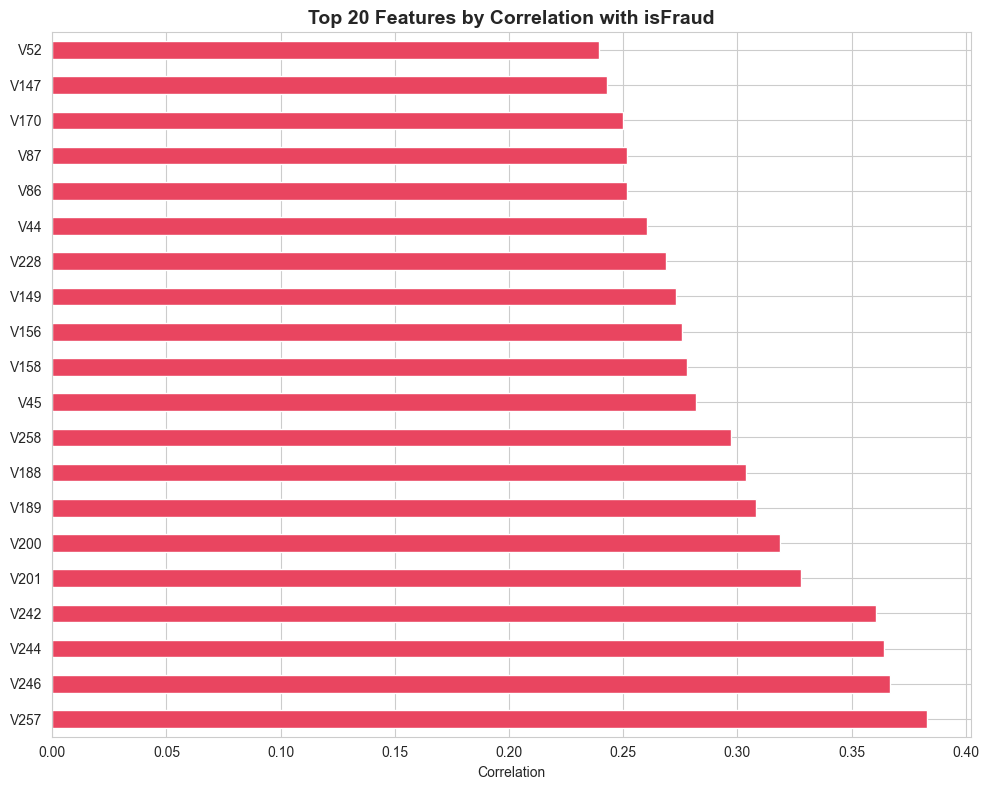

In [6]:
# Top 20 features correlated with isFraud
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
corr_with_target = train[numeric_cols.union(['isFraud'])].corr()['isFraud'].drop('isFraud').sort_values(key=abs, ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e94560' if v > 0 else '#667eea' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top 20 Features by Correlation with isFraud', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()

In [7]:
# Highly correlated feature pairs (redundancy check)
corr_matrix = train[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant = [(upper.columns[i], upper.index[j], upper.iloc[i, j])
             for i in range(len(upper.columns)) for j in range(i+1, len(upper.index))
             if upper.iloc[i, j] > 0.95]

print(f'Redundant pairs (r > 0.95): {len(redundant)}')
for a, b, r in redundant[:10]:
    print(f'  {a} <-> {b}: {r:.3f}')

Redundant pairs (r > 0.95): 598
  C1 <-> C2: 0.995
  C1 <-> C4: 0.968
  C1 <-> C6: 0.982
  C1 <-> C8: 0.968
  C1 <-> C10: 0.958
  C1 <-> C11: 0.997
  C1 <-> C14: 0.952
  C2 <-> C4: 0.972
  C2 <-> C6: 0.975
  C2 <-> C8: 0.976


## 3. Feature Importance (3-Model Comparison)

Compare which features each model considers important.

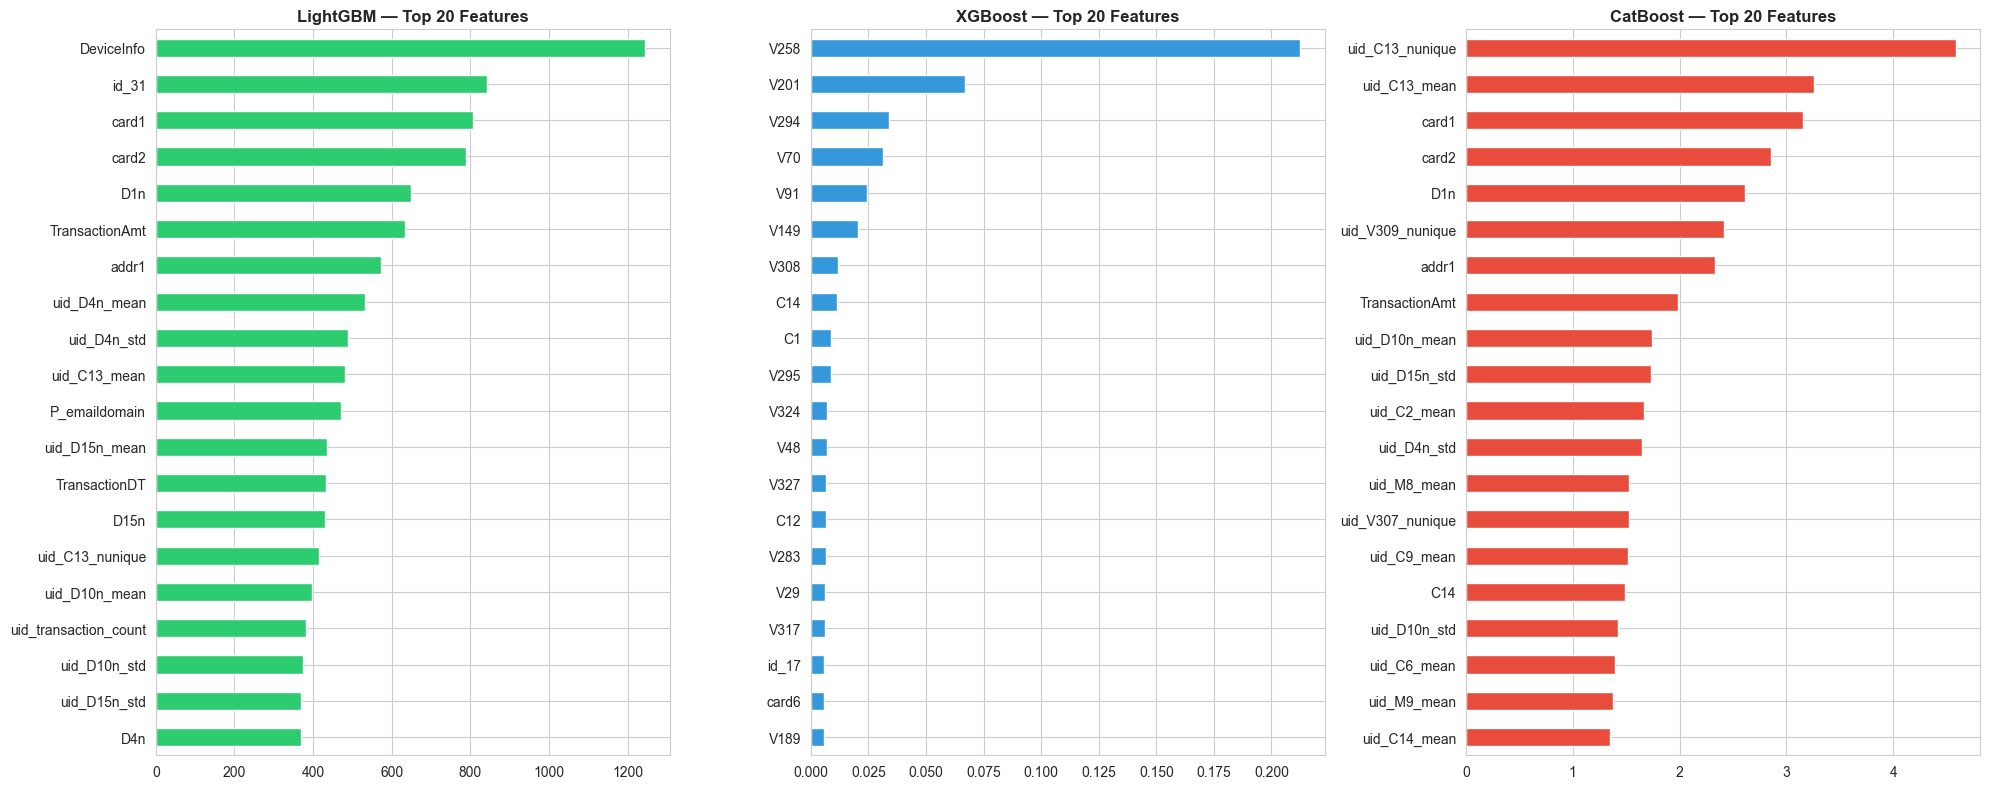

In [8]:
# Extract top 20 features per model
lgb_imp = pd.Series(lgb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(20)
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_train_xgb.columns).sort_values(ascending=False).head(20)
cat_imp = pd.Series(cat_model.get_feature_importance(), index=X_train_cat.columns).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 3, figsize=(20, 8))
for ax, imp, title, color in zip(
    axes, [lgb_imp, xgb_imp, cat_imp],
    ['LightGBM', 'XGBoost', 'CatBoost'],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    imp.plot(kind='barh', ax=ax, color=color)
    ax.set_title(f'{title} — Top 20 Features', fontweight='bold')
    ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Features all 3 models agree on
lgb_set = set(lgb_imp.index)
xgb_set = set(xgb_imp.index)
cat_set = set(cat_imp.index)

common = lgb_set & xgb_set & cat_set
print(f'Features in ALL top-20s: {len(common)}')
for f in sorted(common):
    print(f'  • {f}')

only_cat = cat_set - lgb_set - xgb_set
print(f"\nFeatures only CatBoost cares about: {len(only_cat)}")
for f in sorted(only_cat):
    print(f'  • {f}')

Features in ALL top-20s: 0

Features only CatBoost cares about: 8
  • uid_C14_mean
  • uid_C2_mean
  • uid_C6_mean
  • uid_C9_mean
  • uid_M8_mean
  • uid_M9_mean
  • uid_V307_nunique
  • uid_V309_nunique


## 4. SHAP Values

Understand *why* CatBoost makes each prediction.

**Interpretation:**
- Red = high feature value pushes prediction UP (more fraud)
- Blue = low feature value pushes prediction DOWN (less fraud)

In [10]:
# Sample 1000 rows for SHAP speed
shap_sample = X_test_cat.sample(n=1000, random_state=42)
shap_y = y_test.loc[shap_sample.index]

explainer = shap.TreeExplainer(cat_model)
shap_values = explainer.shap_values(shap_sample)

print('SHAP values computed for 1000 samples.')

SHAP values computed for 1000 samples.


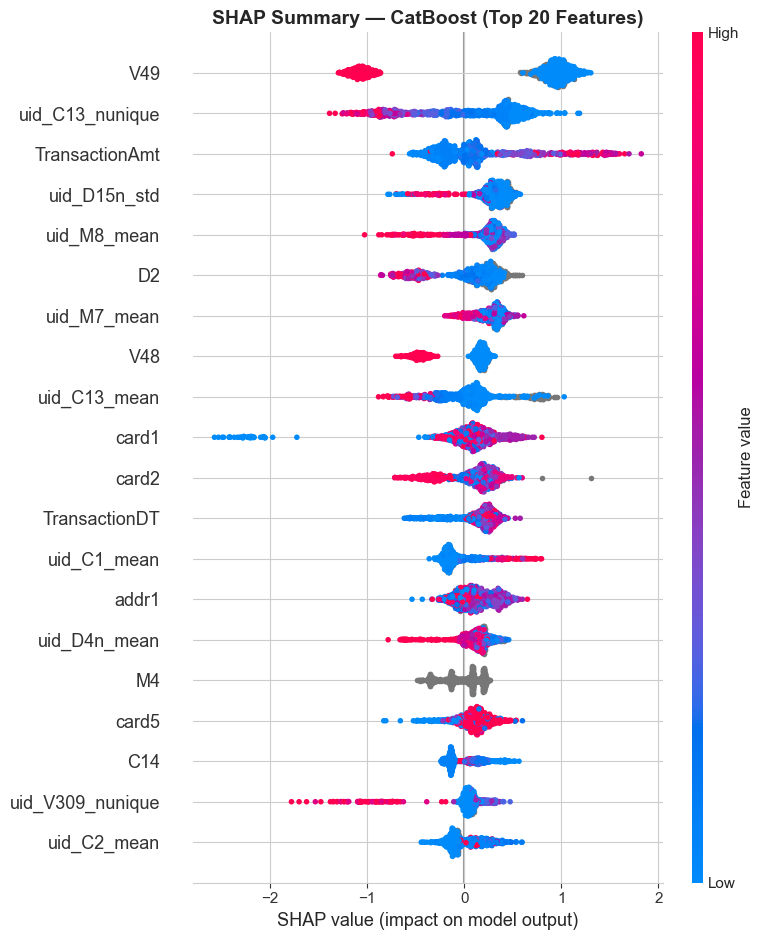

In [11]:
# Summary plot (beeswarm)
shap.summary_plot(shap_values, shap_sample, max_display=20, show=False)
plt.title('SHAP Summary — CatBoost (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

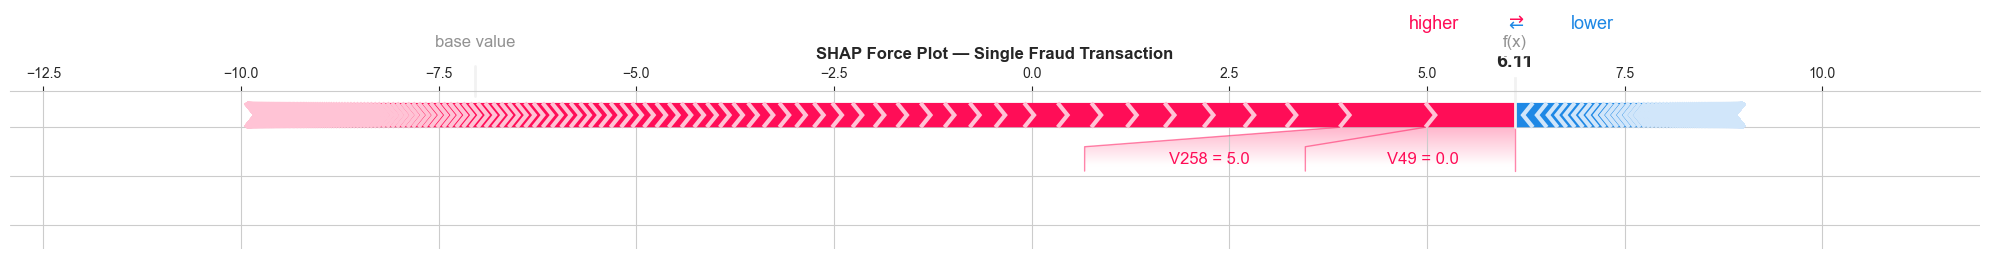

In [12]:
# Force plot for a single fraudulent transaction
fraud_idx = shap_y[shap_y == 1].index[0]
idx_pos = shap_sample.index.get_loc(fraud_idx)

shap.force_plot(
    explainer.expected_value,
    shap_values[idx_pos],
    shap_sample.iloc[idx_pos],
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot — Single Fraud Transaction', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Feature Interaction (CatBoost)

Which pairs of features work together?

C:\Users\moizs\AppData\Local\Temp\ipykernel_11512\764117335.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=inter_df, y='Pair', x='Importance', palette='magma', ax=ax)


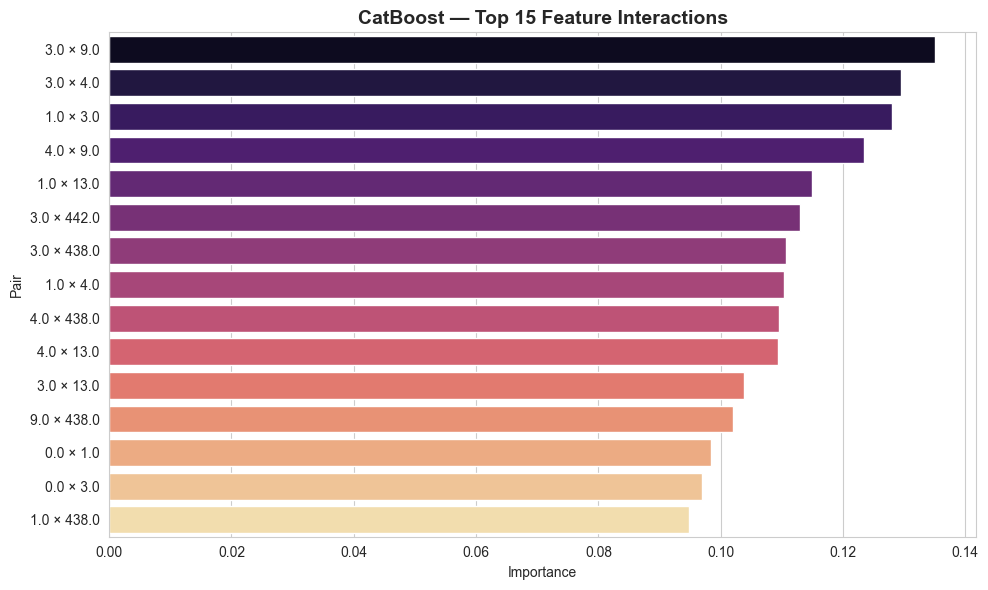

In [15]:
import catboost
# CatBoost interaction strengths
interaction = cat_model.get_feature_importance(
    type='Interaction',
    data=catboost.Pool(X_test_cat, y_test, cat_features=cat_features_idx)
)

inter_df = pd.DataFrame(interaction, columns=['Feature1', 'Feature2', 'Importance'])
inter_df['Pair'] = inter_df['Feature1'].astype(str) + ' × ' + inter_df['Feature2'].astype(str)
inter_df = inter_df.sort_values('Importance', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=inter_df, y='Pair', x='Importance', palette='magma', ax=ax)
ax.set_title('CatBoost — Top 15 Feature Interactions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Feature Distributions (Fraud vs Legit)

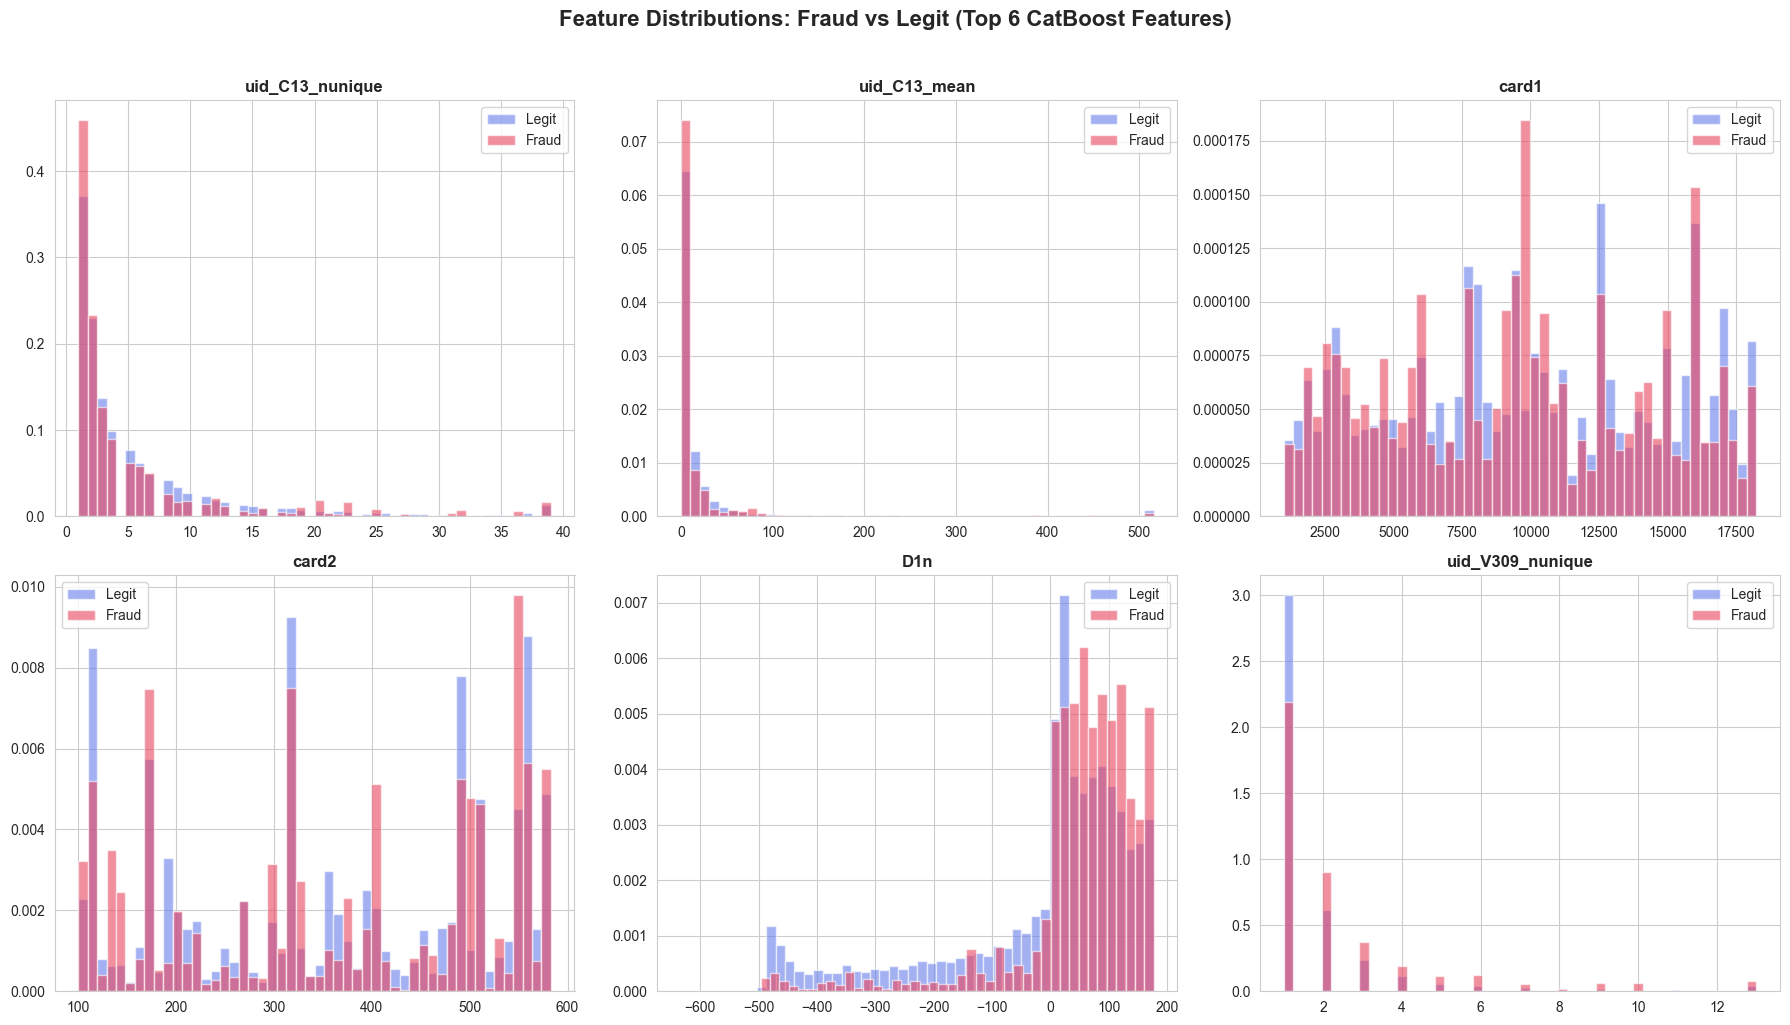

In [16]:
# Pick top 6 features from CatBoost importance
top6 = cat_imp.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, top6):
    fraud_vals = train[train['isFraud'] == 1][col].dropna()
    legit_vals = train[train['isFraud'] == 0][col].dropna()
    
    # Clip extreme outliers for visualization
    q99 = train[col].quantile(0.99)
    fraud_vals = fraud_vals.clip(upper=q99)
    legit_vals = legit_vals.clip(upper=q99)
    
    ax.hist(legit_vals, bins=50, alpha=0.6, label='Legit', color='#667eea', density=True)
    ax.hist(fraud_vals, bins=50, alpha=0.6, label='Fraud', color='#e94560', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend()

plt.suptitle('Feature Distributions: Fraud vs Legit (Top 6 CatBoost Features)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Precision–Recall & ROC Curves

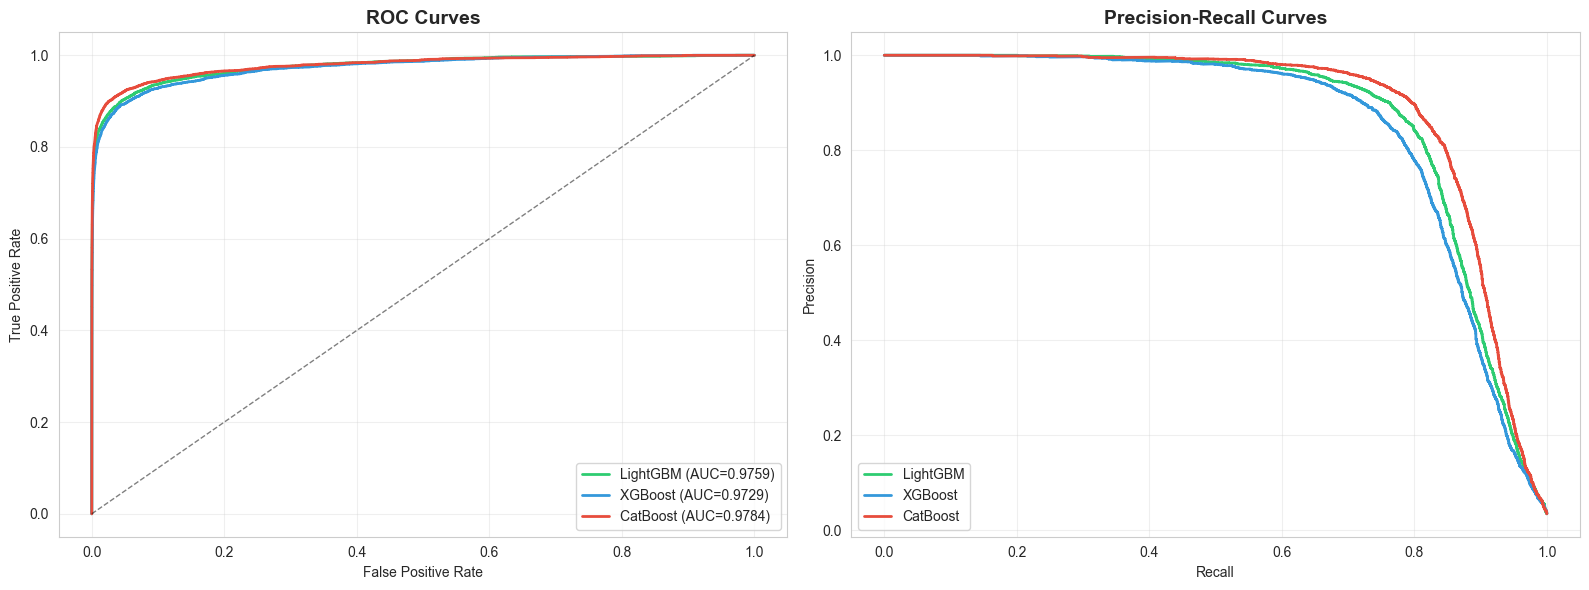

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curves
for name, proba, color in zip(
    ['LightGBM', 'XGBoost', 'CatBoost'],
    [lgb_proba, xgb_proba, cat_proba],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.4f})', color=color, lw=2)

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=14, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall Curves
for name, proba, color in zip(
    ['LightGBM', 'XGBoost', 'CatBoost'],
    [lgb_proba, xgb_proba, cat_proba],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    precision, recall, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(recall, precision, label=name, color=color, lw=2)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Confusion Matrix & Error Analysis

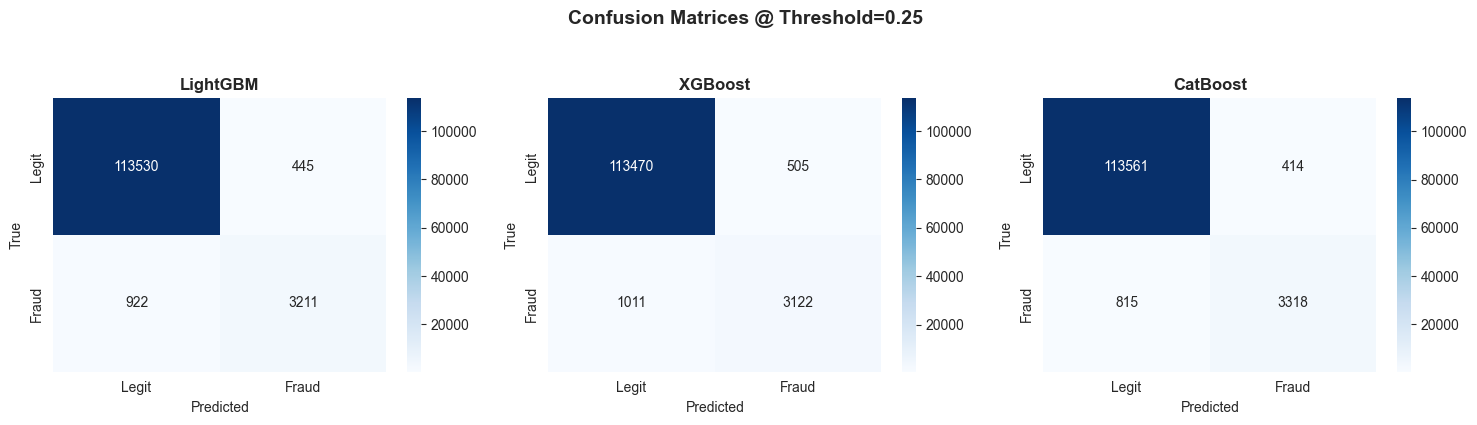

In [18]:
# Confusion matrices at threshold 0.25
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, proba in zip(
    axes, ['LightGBM', 'XGBoost', 'CatBoost'],
    [lgb_proba, xgb_proba, cat_proba]
):
    preds = (proba >= 0.25).astype(int)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    ax.set_title(f'{name}', fontweight='bold')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices @ Threshold=0.25', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [20]:
# Error analysis: False Positives vs False Negatives (CatBoost)
cat_preds = (cat_proba >= 0.25).astype(int)

fp_mask = (cat_preds == 1) & (y_test == 0)  # Predicted fraud, actually legit
fn_mask = (cat_preds == 0) & (y_test == 1)  # Predicted legit, actually fraud

print(f'False Positives: {fp_mask.sum():,} | False Negatives: {fn_mask.sum():,}')
print(f'FP Rate: {fp_mask.sum() / (y_test==0).sum():.4f} | FN Rate: {fn_mask.sum() / (y_test==1).sum():.4f}')

# Compare FP vs FN on key features
# Only numeric columns for mean calculation
num_cols = X_test.select_dtypes(include=[np.number]).columns

fp_means = X_test.loc[fp_mask, num_cols].mean()
fn_means = X_test.loc[fn_mask, num_cols].mean()
legit_means = X_test.loc[y_test == 0, num_cols].mean()
fraud_means = X_test.loc[y_test == 1, num_cols].mean()

diff = pd.DataFrame({
    'FP_vs_Legit': (fp_means - legit_means).abs(),
    'FN_vs_Fraud': (fn_means - fraud_means).abs(),
}).sort_values('FP_vs_Legit', ascending=False).head(10)

print('\nTop features where errors diverge from correct class:')
print(diff)

False Positives: 414 | False Negatives: 815
FP Rate: 0.0036 | FN Rate: 0.1972


c:\Users\moizs\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)



Top features where errors diverge from correct class:
                         FP_vs_Legit    FN_vs_Fraud
TransactionDT          113910.582135  325586.030642
V160                    35851.662109     931.137695
id_02                   21857.078125    3534.921875
uid_transaction_count   17261.297289    4233.078065
V159                     2818.019287     134.227554
V165                     1852.697449      64.000687
V332                     1393.751015     104.298447
V203                     1075.255638     366.333832
V333                     1013.402626      84.010033
V212                      773.645325     189.523444


## 9. Calibration Curve

Does `proba=0.90` actually mean 90% fraud rate?

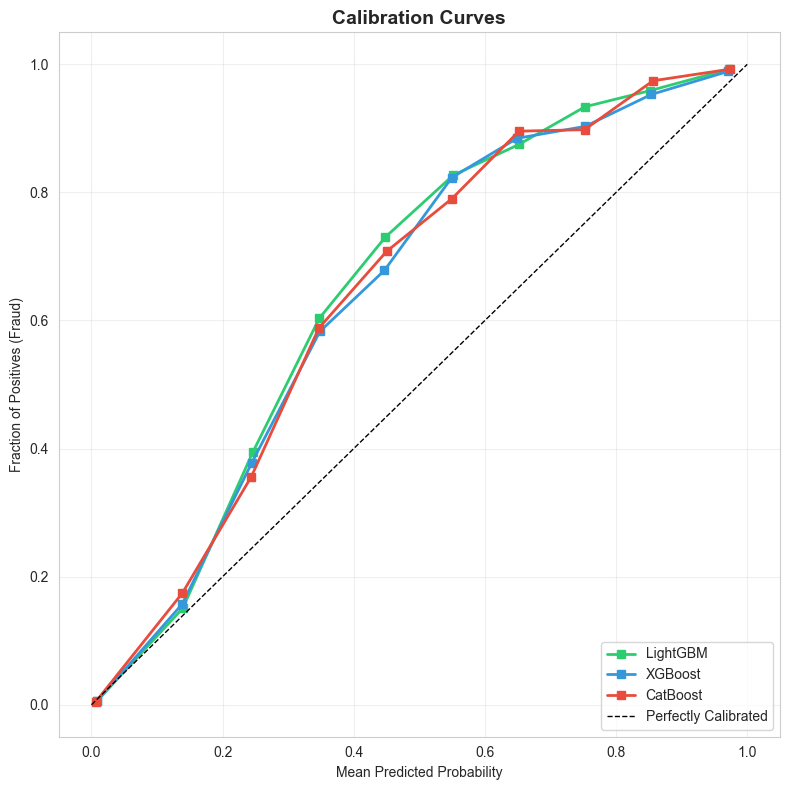

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))

for name, proba, color in zip(
    ['LightGBM', 'XGBoost', 'CatBoost'],
    [lgb_proba, xgb_proba, cat_proba],
    ['#2ecc71', '#3498db', '#e74c3c']
):
    prob_true, prob_pred = calibration_curve(y_test, proba, n_bins=10, strategy='uniform')
    ax.plot(prob_pred, prob_true, 's-', label=name, color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfectly Calibrated')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives (Fraud)')
ax.set_title('Calibration Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Research Conclusions

Summarize findings and decide next steps.

In [22]:
# Auto-generate a research summary table
conclusions = pd.DataFrame({
    'Question': [
        'Which model is best?',
        'What feature type matters most?',
        'Are predictions calibrated?',
        'Where do models fail most?',
        'Any redundant features?',
        'Best threshold?',
    ],
    'Finding': [
        'CatBoost (F1=0.8429, AUC=0.9780)',
        'UID aggregations (D, C, V, M columns)',
        'CatBoost slightly overconfident at high end',
        'FN > FP — missing subtle fraud patterns',
        f'{len(redundant)} highly correlated pairs found',
        '0.25 optimal for F1',
    ],
    'Next_Action': [
        'Stack LGBM on top of 3 models',
        'Add more V-column aggregations',
        'Apply Platt scaling or isotonic regression',
        'Focus on FN samples — what do they share?',
        'Remove redundant pairs, retrain',
        'Keep 0.25 for now; test 0.20 for recall',
    ]
})

print(conclusions.to_string(index=False))

                       Question                                     Finding                                Next_Action
           Which model is best?            CatBoost (F1=0.8429, AUC=0.9780)              Stack LGBM on top of 3 models
What feature type matters most?       UID aggregations (D, C, V, M columns)             Add more V-column aggregations
    Are predictions calibrated? CatBoost slightly overconfident at high end Apply Platt scaling or isotonic regression
     Where do models fail most?     FN > FP — missing subtle fraud patterns  Focus on FN samples — what do they share?
        Any redundant features?           598 highly correlated pairs found            Remove redundant pairs, retrain
                Best threshold?                         0.25 optimal for F1    Keep 0.25 for now; test 0.20 for recall
